## Figure S4

### Hi-C matrices of chromosomes V and X in P. pacificus before and after rescaffolding and manual curation

Import packages

In [1]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import cooler
import bioframe

import cooltools
import cooltools.expected
from cooltools import snipping

import cooltools.lib.plotting
# Set up parallelization
import multiprocess

from matplotlib.colors import LogNorm
from scipy import interpolate
from mpl_toolkits.axes_grid import make_axes_locatable
import pyBigWig
import csv

from cooltools.lib.numutils import adaptive_coarsegrain, interp_nan

# Import python package for working with cooler files and tools for analysis
from cooltools.insulation import calculate_insulation_score, find_boundaries

# check the version (0.4.0)
cooltools.__version__ 

/state/partition1/job-2189958/ipykernel_1542681/4050152799.py:19: MatplotlibDeprecationWarning: 
The mpl_toolkits.axes_grid module was deprecated in Matplotlib 2.1 and will be removed two minor releases later. Use mpl_toolkits.axes_grid1 and mpl_toolkits.axisartist, which provide the same functionality instead.
  from mpl_toolkits.axes_grid import make_axes_locatable


'0.4.0'

Load cool cool file

In [2]:
bin = str(5000) # resolution of cool file

PRJNA12644 = cooler.Cooler("".join(["/home/aa7013/hic-to-cool/PS312_JK88_JK122_PRJNA12644-WBPS16/PS312_JK88_JK122_PRJNA12644-WBPS16_30_",bin,"_raw.cool"]))
PRJNA12644_RS = cooler.Cooler("".join(["/home/aa7013/hic-to-cool/PS312_JK88_JK122_PRJNA12644-WBPS16-RS/PS312_JK88_JK122_PRJNA12644-WBPS16-RS_30_",bin,"_raw.cool"]))

Define variables to smooth matrix and format ticks (these functions were taken from the cooltools documentation)

In [3]:
def cgi_region(clr,region):
    cg = adaptive_coarsegrain(clr.matrix(balance=True).fetch(region),
                              clr.matrix(balance=False).fetch(region),
                              cutoff=3, max_levels=8)
    cgi = interp_nan(cg) # don't interpolate when lots of empty bins. set return(cg) to skip interpolation.
    return(cg)

from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')

def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

Plot Hi-C matrices for chromosome X

/ext3/miniconda3/lib/python3.9/site-packages/cooltools/lib/numutils.py:1355: RuntimeWarning: invalid value encountered in true_divide
  val_cur = ar_cur / armask_cur


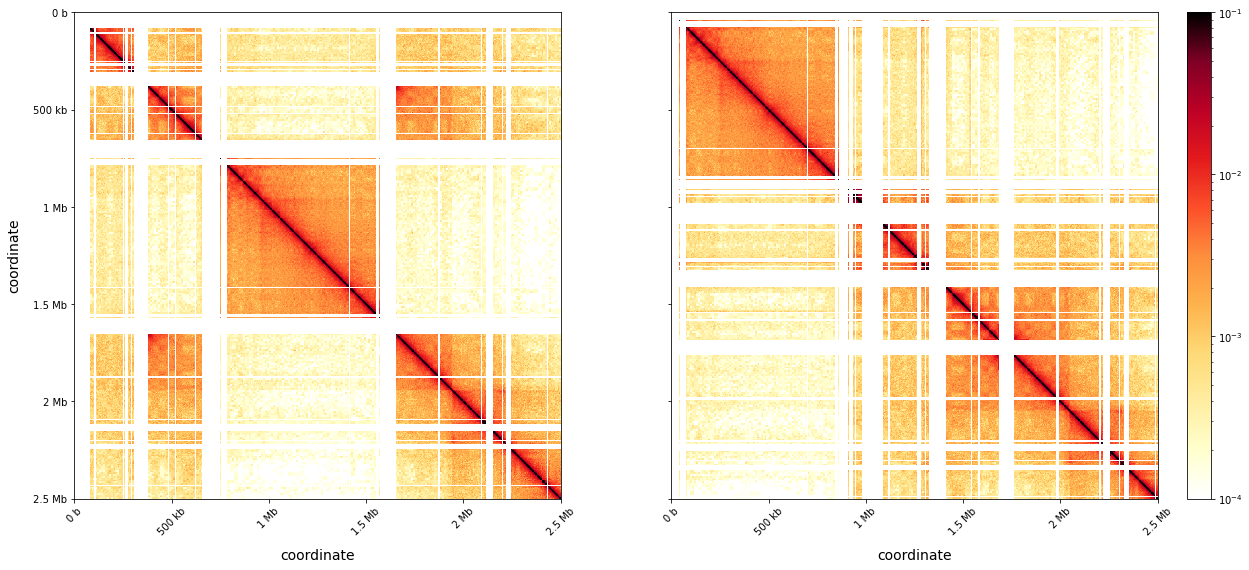

In [4]:
f, axs = plt.subplots(
    figsize=(18, 8),
    nrows=1,
    ncols=2,
    sharex=False,
    sharey=True)

start, end = 0_000_000, 2_500_000
region = ('PPA_X', start, end)
region_RS = ('X', start, end)
norm = LogNorm(vmin=0.0001, vmax=0.1)

ax = axs[0]
clr_region = cgi_region(PRJNA12644, region)
im = ax.matshow(
    clr_region,
    norm=norm,
    cmap="fall",
    extent=(start, end, end, start))
ax.set_xlabel('coordinate', fontsize=14, labelpad=12.0)
ax.set_ylabel('coordinate', fontsize=14, labelpad=12.0)
format_ticks(ax)

ax = axs[1]
clr_region = cgi_region(PRJNA12644_RS, region_RS)
im = ax.matshow(
    clr_region,
    norm=norm,
    cmap="fall",
    extent=(start, end, end,start))
plt.colorbar(im, fraction=0.046, pad=0.05)
ax.set_xlabel('coordinate', fontsize=14, labelpad=12.0)
format_ticks(ax)

plt.tight_layout()

plt.savefig('ChrX_before_after.pdf', format='pdf', dpi=300)

Plot Hi-C matrices for chromosome V

/ext3/miniconda3/lib/python3.9/site-packages/cooltools/lib/numutils.py:1355: RuntimeWarning: invalid value encountered in true_divide
  val_cur = ar_cur / armask_cur


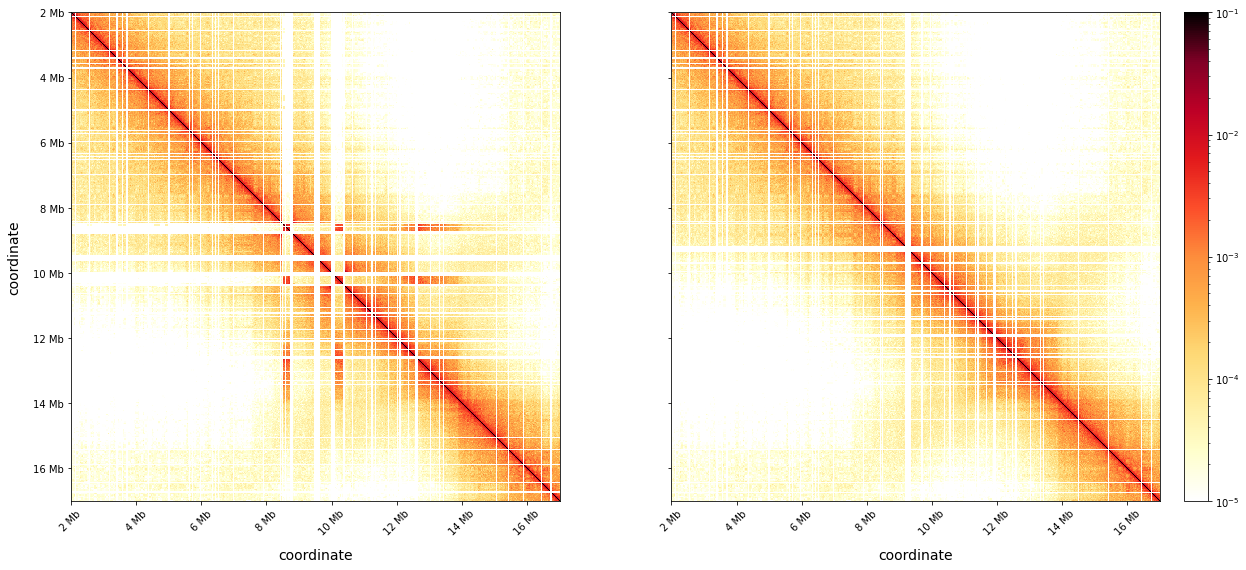

In [5]:
f, axs = plt.subplots(
    figsize=(18, 8),
    nrows=1,
    ncols=2,
    sharex=False,
    sharey=True)

start, end = 2_000_000, 17_000_000
region = ('PPA_V', start, end)
region_RS = ('V', start, end)
norm = LogNorm(vmin=0.00001, vmax=.1)

ax = axs[0]
clr_region = cgi_region(PRJNA12644, region)
im = ax.matshow(
    clr_region,
    norm=norm,
    cmap="fall",
    extent=(start, end, end, start))
ax.set_xlabel('coordinate', fontsize=14, labelpad=12.0)
ax.set_ylabel('coordinate', fontsize=14, labelpad=12.0)
format_ticks(ax)

ax = axs[1]
clr_region = cgi_region(PRJNA12644_RS, region_RS)
im = ax.matshow(
    clr_region,
    norm=norm,
    cmap="fall",
    extent=(start, end, end,start))
plt.colorbar(im, fraction=0.046, pad=0.04)
ax.set_xlabel('coordinate', fontsize=14, labelpad=12.0)
format_ticks(ax)

plt.tight_layout()

plt.savefig('ChrV_before_after.pdf', format='pdf', dpi=300)